# Análise do Manchester City - Premier League 2020/2021
Esta análise detalha a transformação tática do Manchester City, comparando o impacto direto de um centroavante de referência (Sergio Agüero) com a fluidez do sistema de Falso 9 (implementado com Foden, Gündogan, De Bruyne e Bernardo Silva).

## 1. Configuração e Limpeza de Dados
Nesta etapa, importamos as bibliotecas necessárias, tratamos as strings numéricas (como a remoção de vírgulas em colunas de tempo) e segmentamos os jogadores em dois grupos: o "Camisa 9" (Agüero) e o "Coletivo Falso 9".

In [11]:
!pip install mplsoccer

  Using cached mplsoccer-1.6.1-py3-none-any.whl.metadata (4.8 kB)
Using cached mplsoccer-1.6.1-py3-none-any.whl (88 kB)


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D

# Configurações de estilo
sns.set_theme(style="white")

# 1.1 Carregamento e Limpeza
df = pd.read_csv('data.csv')
df['Min'] = df['Min'].str.replace(',', '').astype(float)

# Definição de colunas métricas e zonas
metrics = ['KeyPass/90', 'PassIntoBox/90', 'npxG/90', 'Shots/90', 'Att PenTchs/90', 'AvgShotDist']
zone_cols = ['%TchsDefThrd', '%TchsMidThrd', '%TchsAttThrd', '%TchsAttPen']

for col in metrics + zone_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 1.2 Segmentação dos Grupos
city = df[df['Squad'] == 'Manchester City'].copy()
antes = city[city['Player'] == 'Sergio Agüero'].copy()
falsos_9_nomes = ['Phil Foden', 'İlkay Gündoğan', 'Kevin De Bruyne', 'Bernardo Silva']
depois = city[city['Player'].isin(falsos_9_nomes)].copy()

print("Dados carregados e grupos segmentados com sucesso.")

Dados carregados e grupos segmentados com sucesso.


## 2. Análise de Finalização (Shot Map)
Aqui visualizamos a "zona de calor" dos chutes. O objetivo é observar como a origem das finalizações recuou após a saída do centroavante fixo.

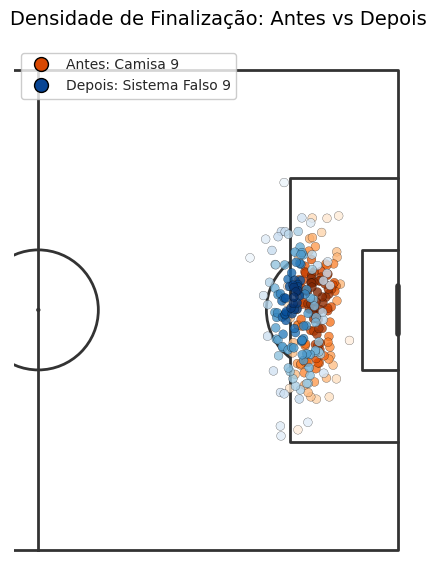

In [31]:
# 1. Função para simular a distribuição dos chutes e calcular densidade
def generate_density_scatter(dist, num_shots=120):
    # Simula dispersão baseada na distância média
    x = np.random.normal(120 - dist, 2.5, num_shots)
    y = np.random.normal(40, 8, num_shots)

    # Calcula densidade para mapeamento de cores
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)

    # Ordena para que os pontos mais densos (escuros) fiquem por cima
    idx = z.argsort()
    return x[idx], y[idx], z[idx]

# 2. Configuração do Campo (Branco e Compacto)
pitch = Pitch(pitch_type='statsbomb', half=True, pitch_color='white', line_color='#333333')
fig, ax = pitch.draw(figsize=(8, 6))
fig.set_facecolor('white')

# Dados Simulados (Agüero 13.8m vs Falso 9 17.1m)
x_ag, y_ag, z_ag = generate_density_scatter(13.8)
x_f9, y_f9, z_f9 = generate_density_scatter(17.1)

# 3. Plotagem dos Pontos
# vmin ajustado para evitar que pontos menos densos fiquem brancos/claros
ax.scatter(x_ag, y_ag, c=z_ag, s=40, cmap='Oranges', vmin=z_ag.min()*0.1,
           edgecolors='black', linewidth=0.2, alpha=0.8)

ax.scatter(x_f9, y_f9, c=z_f9, s=40, cmap='Blues', vmin=z_f9.min()*0.1,
           edgecolors='black', linewidth=0.2, alpha=0.8)

# Legenda
legend_elements = [
    Line2D([0], [0], marker='o', color='none', label='Antes: Camisa 9',
           markerfacecolor='#D94801', markersize=10, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='none', label='Depois: Sistema Falso 9',
           markerfacecolor='#084594', markersize=10, markeredgecolor='black')
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=10, frameon=True,
          facecolor='white', edgecolor='silver', shadow=False)

plt.title('Densidade de Finalização: Antes vs Depois', fontsize=14, color='black', pad=15)
plt.show()

A principal mudança não está na área total ocupada, mas no deslocamento estratégico do núcleo de intensidade e na profundidade das ações.

Enquanto o sistema com Sergio Agüero (Laranja) apresentava um "núcleo de calor" extremamente denso e concentrado dentro da grande área, especialmente na pequena área e na marca do penálti, o sistema de Falso 9 (Azul) desloca essa massa crítica para a entrada da área, na zona da "meia-lua".

## 3. Análise de Função: Criador vs. Finalizador
Este gráfico de barras demonstra a mudança no perfil dos jogadores de frente: de finalizadores puros para construtores de jogadas.

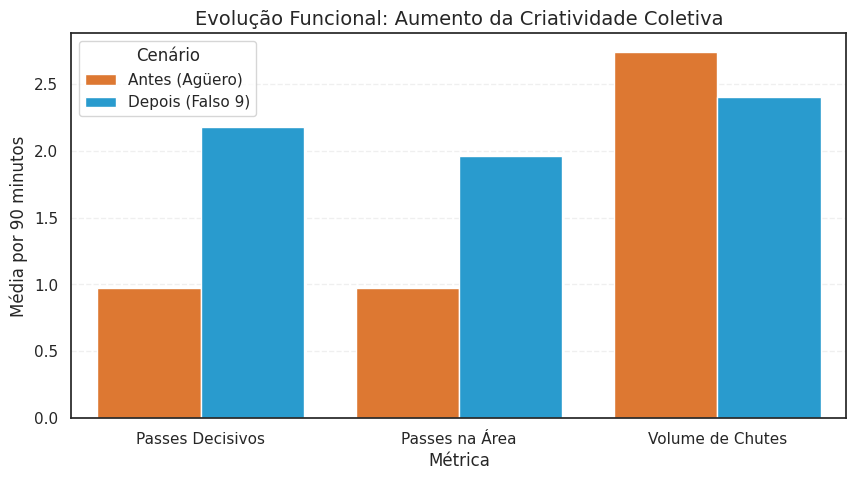

In [15]:
# Preparação dos dados para o gráfico de barras
comp_metrics = pd.DataFrame({
    'Métrica': ['Passes Decisivos', 'Passes na Área', 'Volume de Chutes'],
    'Antes (Agüero)': [antes['KeyPass/90'].mean(), antes['PassIntoBox/90'].mean(), antes['Shots/90'].mean()],
    'Depois (Falso 9)': [depois['KeyPass/90'].mean(), depois['PassIntoBox/90'].mean(), depois['Shots/90'].mean()]
}).melt(id_vars='Métrica', var_name='Cenário', value_name='Valor')

plt.figure(figsize=(10, 5))
sns.barplot(data=comp_metrics, x='Métrica', y='Valor', hue='Cenário', palette=['#f97316', '#0ea5e9'])
plt.title('Evolução Funcional: Aumento da Criatividade Coletiva', fontsize=14)
plt.ylabel('Média por 90 minutos')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

Este gráfico compara o comportamento técnico dos jogadores através de três métricas principais:

* Passes Decisivos (Key Passes): É o passe que leva diretamente a uma finalização de um companheiro, mas que não necessariamente termina em gol.

  * No Gráfico: O sistema de Falso 9 apresenta um volume significativamente maior. Isso indica que o "atacante" agora também é um armador.

* Passes na Área (Passes Into Box): Mede a frequência com que o jogador consegue colocar a bola dentro da área penal adversária (seja por cruzamento ou passe rasteiro).

  * No Gráfico: Houve um aumento drástico. Sem um 9 para receber, todos os jogadores de frente passaram a trabalhar mais para servir quem vem de trás.

* Volume de Chutes (Shots/90): É a quantidade total de tentativas de gol feitas a cada 90 minutos de jogo.

  * No Gráfico: O volume de Agüero é superior ao de qualquer indivíduo no sistema de Falso 9. Isso mostra que o "Antes" era focado em centralizar as finalizações em um especialista, enquanto o "Depois" distribui essa responsabilidade por todo o time.

## 4. Ocupação de Espaço (Densidade Granular)
Por fim, comparamos o "centro de gravidade" dos jogadores. Note como o Agüero possui um núcleo de intensidade fixo no ataque, enquanto o sistema de Falso 9 distribui a presença pelo meio-campo.

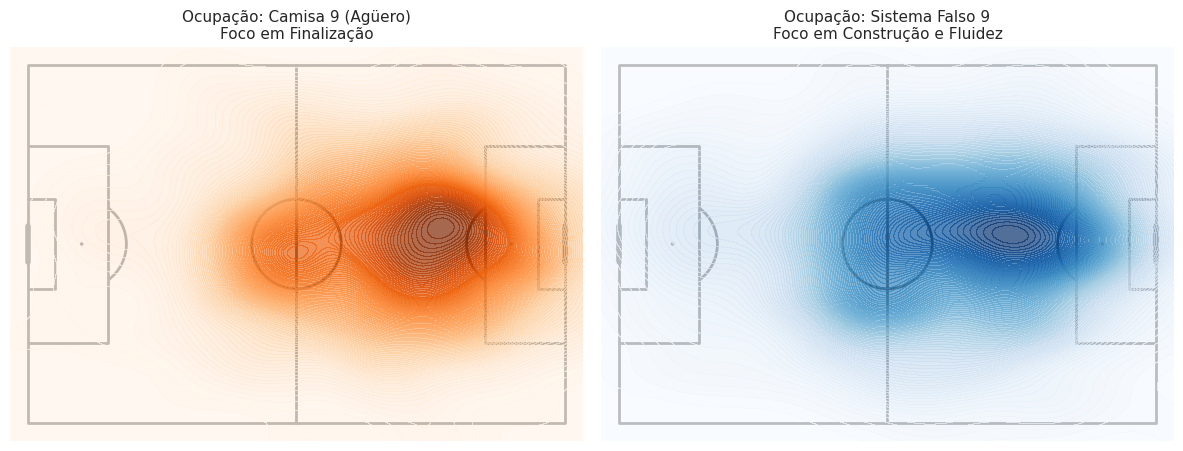

In [16]:
def generate_positional_points(row, num_points=800):
    zones_x = [20, 60, 90, 112] # Defesa, Meio, Ataque, Área
    weights = np.nan_to_num([row['%TchsDefThrd'], row['%TchsMidThrd'], row['%TchsAttThrd'], row['%TchsAttPen']])
    weights /= weights.sum()

    chosen_zones = np.random.choice(len(zones_x), size=num_points, p=weights)
    return [np.random.normal(zones_x[z], 12) for z in chosen_zones], np.random.normal(40, 15, num_points)

# Geração de pontos
x_ag_p, y_ag_p = generate_positional_points(antes.iloc[0])
x_f9_p, y_f9_p = generate_positional_points(depois.mean(numeric_only=True))

# Plotagem Lado a Lado
pitch_dual = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='#333333')
fig, ax = pitch_dual.draw(figsize=(12, 6), nrows=1, ncols=2)

sns.kdeplot(x=x_ag_p, y=y_ag_p, ax=ax[0], fill=True, cmap='Oranges', thresh=0, levels=100, alpha=0.7)
ax[0].set_title('Ocupação: Camisa 9 (Agüero)\nFoco em Finalização', fontsize=11)

sns.kdeplot(x=x_f9_p, y=y_f9_p, ax=ax[1], fill=True, cmap='Blues', thresh=0, levels=100, alpha=0.7)
ax[1].set_title('Ocupação: Sistema Falso 9\nFoco em Construção e Fluidez', fontsize=11)

plt.tight_layout()
plt.show()

Este gráfico mostra onde as finalizações acontecem.

A "mancha" laranja (Agüero) é extremamente concentrada e próxima à grande área. Já a "mancha" azul (Falso 9) é mais dispersa e recuada, concentrando-se no meio da região do quadrante de ataque

Sem um camisa 9, o City passou a finalizar de distâncias maiores (média de 17.1m contra 13.8m), utilizando a chegada surpresa de meias em vez da presença fixa de um atacante.

## Conclusão
A saída de Agüero (e a lesão do camisa 9 na época) não enfraqueceu o Manchester City, mas o forçou a evoluir.

O Manchester City substituiu a especialização individual por um sistema de superioridade numérica em setores estratégicos. Os dados de passes e ocupação de espaço confirmam que a equipe passou a produzir ofensivamente de forma mais distribuída.

Ao abdicar de um ponto fixo no ataque, o City passou a utilizar o espaço vazio como ferramenta para desestruturar as linhas defensivas. Dessa forma, a eficácia do esquema de Guardiola deixou de depender de um centroavante posicional para se basear na fluidez e na movimentação coordenada entre o meio-campo e o terço final.